### **tensor prep**

In [1]:
# Imports
import os
import re
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt

# ----File Stitching----
# If in prep folder, cd back to base repository folder
if os.path.basename(os.getcwd()) == "prep":
    os.chdir('../..')

# Control which user's files are accessed
match_sk = 'sophiekim'
match_hc = 'hayeonchung'
match_ck = 'Caroline'
match_st = 'student'
path_str = os.getcwd()
print(path_str)
if re.search(match_sk, path_str):
    os.chdir("/Users/sophiekim/Desktop/2_research/MamalakisResearch") 
    user = match_sk
    print("Sophie Kim recognized as user.")
elif re.search(match_hc, path_str):
    os.chdir("/Users/hayeonchung/Downloads/Mamalakis Graduate Research/MamalakisResearch") 
    user = match_hc
    print("Hayeon Chung recognized as user.")
elif re.search(match_ck, path_str):
    os.chdir("/Users/Caroline/Desktop/school/MamalakisResearch") 
    user = match_ck
    print("Caroline Kranefuss recognized as user.")
elif re.search(match_st, path_str):
    os.chdir("/Users/student/Desktop/mamalakis_research/MamalakisResearch")
    user = match_st
    print("Student recognized as user.")
else:
    print("User not recognized. Please manually change directory.")

c:\Users\student\Desktop\mamalakis_research\MamalakisResearch
Student recognized as user.


In [3]:
# Assign base path
base_path ='/Users/sophiekim/Desktop/2_research/MamalakisResearch'
base_path = os.getcwd()

# All users should have locally loaded 'data' folder
data_path = base_path + '/data/'

In [4]:
# initializing model list variable to call in function
model_list = [
    "CNRM_ESM2-1_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MIROC6_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MPI-ESM1-2-LR_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MRI-ESM2-0_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "UKESM1-0-LL_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
]

In [5]:
# pulling variables out for the plot function 
VAR_LIST = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]

# dictionary for each unit for the plot 
UNIT_MAP = {
    "tas": "°C", 
    "tasmax": "°C", 
    "tasmin": "°C", 
    "pr": "mm/day", 
    "psl": "hPa", 
    "sfcWind": "m/s", 
    "mrsos": "kg/m²"}

In [6]:
def convert_units(varname: str, x: np.ndarray):
    """
    varname: index number from the list of variables so get_data func can convert units 
    x: data that needs units changed (raw x data) in get_data func 
    """
    if varname in {"tas", "tasmax", "tasmin"}:
        # kelvin to celsius
        return x - 273.15, "$^{\circ}$C"
    if varname == "pr":
        # kg/(m2*s) to mm/day
            # 1kg/m2 = 1 mm 
        return x * 86400.0, "mm/day"
    if varname == "psl":
        # pascals to hpa
        return x / 100.0, "hPa"
    
    # these don't need to be converted -- just adding the units 
    if varname == "sfcWind":
        return x, "m/s"
    if varname == "mrsos":
        return x, "kg/m$^{2}$"
    return x, "unknown"

In [7]:
def get_model_name(path: str) -> str:
    """
    helper function so that get_cnn_tensors prints out the models that are being processed
    pulled from hayeon's code 
    """
    # Everything before "_ssp..."
    return os.path.basename(path).split("_ssp")[0]

In [ ]:
def get_cnn_tensors(model_list, scenario, data_path, 
                    st_early=2015, end_early=2024, 
                    st_late=2055, end_late=2064,
                    stat='mean', use_anomaly=True, 
                    models_to_run=None, file_start_year=2015, 
                    vars_to_use=None):
    
    """
    model_list: variable of list of models
    scenario: input as either 'ssp119' or 'ssp126' strings
    data_path: variable of data_path for user
    st_early: early period start yr integer
    end_early: early period end yr integer
    st_late: late period start yr integer
    end_late: late period end yr integer
    stat: what stat function user wants to run to summarize variables 
        mean: mean
        std: standard deviation
        max: max val
        min: min val
        medium: median
    use_anomaly: whether to subtract values from baseline values to find anomaly
        True: subtract values
        False: don't subtract values 
    models_to_run: can specify number of models to run by index of model_list variable
        None: all models 
        [x]: one model to run 
        [x, x, x...]: whatever number of models to run 
    file_start_year: ensuring that if time dimension in models starts at 0 or 1, the func will slice the time correctly 
    vars_to_use: give list of strings of vars to calculate, if none specified (aka default) then does all 7 vars
    """
    # defining variable list for unit conversion later 
    var_list = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]
    # default of calculating with all 7 vars
    if vars_to_use is None:
        selected_vars = var_list
    # if user specified certains vars to be calculated
    else:
        # check to see that the string items provided do exist
        selected_vars = [v for v in vars_to_use if v in var_list]

    # find the indexes of the specified variables defined by user (or defaulting to finding all the vars' indices)
    var_indices = [var_list.index(v) for v in selected_vars]

    # mapping out stats and the relevant func
    stat_map = {'mean': np.nanmean, 'std': np.nanstd, 'max': np.nanmax, 'min': np.nanmin, 'median': np.nanmedian}
    # variable that will calculate the stat for whatever the user wants and then will default to mean (could also leave open-ended) 
    calc_func = stat_map.get(stat.lower(), np.nanmean)

    # runs all models
    if models_to_run is None:
        selected_models = model_list
    # runs one model if user only specified one (int not list)
    elif isinstance(models_to_run, int):
        selected_models = [model_list[models_to_run]]
    # if none of the above options (all or one) was selected, then was list of models so get those models 
    else:
        selected_models = [model_list[i] for i in models_to_run]

    # initializing lists 
    x_list, y_list = [], []

    # opening file for each model 
    for filename in selected_models:
        full_path = os.path.join(data_path, filename)
        model_short_name = get_model_name(filename)
        print(f"processing model: {model_short_name}")
        
        with nc.Dataset(full_path) as ds:
            # loading the data for specific model 
                # slicing dimensions for the ensembles, the specific var indices and all the times/lon/lat dimensions
            data_all_vars = ds[f"data_{scenario}"][:, var_indices, :, :, :] 

            # data_all_vars[data_all_vars > 1e10] = np.nan #FIX BIG VALS TO NAN -- THIS DIDN'T WORK
            # data_all_vars[np.abs(data_all_vars) > 1e10] = np.nan # FIX DIDNT WORK

            data_all_vars = data_all_vars.filled(np.nan)

            all_baseline_avgs = []
            all_baseline_stds = []
            # starting unit conversions for ALL variables
            # looping through all 7 vars or the selected vars only 
                # using enumerate to keep track of the index of var and what the var is in the var_list defined above
                    # idx to keep track of what slice of the var dimension 
                    # var_name so that convert_units can be called correctly 
            for idx, var_name in enumerate(selected_vars):
                # converting var to relevant unit from func -- slicing the relevant var one at a time (getting all the info for all the other dimensions, just associated with that certain var)
                    # returns the converted numbers and string that gives converted unit
                converted_data, _ = convert_units(var_name, data_all_vars[:, idx, :, :, :])
                data_all_vars[:, idx, :, :, :] = converted_data
         
            
                # baseline = first 10 yrs --> for one variable
                baseline_slice = data_all_vars[:, idx, 0:120, :, :] #(5, 120, 144, 73)
                #print(baseline_slice.shape)

                n_models, n_months, n_lat, n_lon = baseline_slice.shape 
                n_years = n_months // 12 # 10 # Reshape to (5, 10, 12, 144, 73), then mean over the months axis 
                yearly_baseline_slices = baseline_slice.reshape(n_models, n_years, 12, n_lat, n_lon).mean(axis=2) # (5, 10, 144, 73)

            
                
                # average ensembles (0 dimen) and yrs (1 dimen)
                var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1))  # (144, 73) -- one global map per variable and model 
                # print(p_mean.shape)
      
                

                all_baseline_avgs.append(var_avg)
          

                # interannual variability within baseline period 
                #var_std = np.nanstd(yearly_baseline_slices, axis=(0,1)) # (144, 73)
                # print(var_std.shape)
                

               # threshold = np.nanquantile(var_std, 0.50)
                # make any std variable value that is less than or equal to threshold NAN 
                
              #  var_std = np.where(var_std <= threshold, np.nan, var_std) 
               # all_baseline_stds.append(var_std)
                squared_diffs = (yearly_baseline_slices - var_avg)**2
                print(squared_diffs.shape)
                var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)))

                # 1% quantile threshold 
                threshold = np.nanquantile(var_std, 0.01)
                            # make any std variable value that is less than or equal to threshold NAN         
                var_std = np.where(var_std <= threshold, np.nan, var_std) 


                # DYNAMIC THRESHOLD 
                # 1. Find the average variance for this specific map's history
               # var_mean_std = np.nanmean(var_std)

                # 2. Set the dynamic noise floor (1% of the map's average)
                #dynamic_threshold = var_mean_std * 1e-2

                # 3. Mask out the microscopic noise (turn to NaN)
                #var_std = np.where(var_std < dynamic_threshold, np.nan, var_std)

                all_baseline_stds.append(var_std)
                            
            var_std_array = np.array(all_baseline_stds)
            


            
            var_avg_array = np.array(all_baseline_avgs) # (7, 144, 73)
            print(var_avg_array.shape)

            
            
            # making list of periods where early period assigned 0 and late assigned 1 
            periods = [(st_early, end_early, 0), (st_late, end_late, 1)]

            # going thru periods 
            for start_yr, end_yr, label in periods:
                # making var for the number of ensembles that are getting looked at 
                n_ens = data_all_vars.shape[0]
                
                # going thru every yr within each period 
                for yr_idx in range(start_yr, end_yr + 1):
                    # indexing by month 
                    m_idx_start = (yr_idx - file_start_year) * 12
                    m_idx_end = m_idx_start + 11 # ??? We think
                    
                    # going thru individual ensemble for current yr 
                    for ens_idx in range(n_ens):
                        # slicing to get the info at the ensemble index, all vars, time index, all lats/longs
                        annual_slice = data_all_vars[ens_idx, :, m_idx_start:m_idx_end+1, :, :]
                        # applying user specified stat func to make the monthly vals into aggregated yearly vals
                        yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)

                       
                        if use_anomaly:
                            # calculate val from subtracting the value from the above calculated mean and then divide by standard deviation
                            val = (yearly_val - var_avg_array) / var_std_array
                        else:
                            val = yearly_val
                        
                        x_list.append(val)
                        y_list.append(label)
    x_list = np.nan_to_num(np.array(x_list), nan=0.0)
    y_list = np.array(y_list).reshape(-1, 1)

    return x_list, y_list, var_std_array

In [19]:
X_data, y_data, var_std_array = get_cnn_tensors(model_list, 'ssp119', data_path, use_anomaly=True) 
# using 2015-2024 for early and 2055-2064 for late & ssp119 for scenario 

processing model: CNRM_ESM2-1


C:\Users\student\AppData\Local\Temp\ipykernel_11632\3175773502.py:104: RuntimeWarning: Mean of empty slice
  var_avg = np.nanmean(yearly_baseline_slices, axis=(0,1))  # (144, 73) -- one global map per variable and model
C:\Users\student\AppData\Local\Temp\ipykernel_11632\3175773502.py:124: RuntimeWarning: Mean of empty slice
  var_std = np.sqrt(np.nanmean(squared_diffs, axis=(0,1)))


(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(7, 144, 73)


C:\Users\student\AppData\Local\Temp\ipykernel_11632\3175773502.py:173: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=1) # (7, 144, 73)


processing model: MIROC6
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(7, 144, 73)


C:\Users\student\AppData\Local\Temp\ipykernel_11632\3175773502.py:178: RuntimeWarning: invalid value encountered in divide
  val = (yearly_val - var_avg_array) / var_std_array


processing model: MPI-ESM1-2-LR
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(7, 144, 73)
processing model: MRI-ESM2-0
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(7, 144, 73)


C:\Users\student\AppData\Local\Temp\ipykernel_11632\3175773502.py:178: RuntimeWarning: divide by zero encountered in divide
  val = (yearly_val - var_avg_array) / var_std_array


processing model: UKESM1-0-LL
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(5, 10, 144, 73)
(7, 144, 73)


In [15]:
import xarray as xr 

# save tensor prep nc file
ds = xr.Dataset(
    data_vars={
        "x_data": (["sample", "variable", "lon", "lat"], X_data),
        "y_label": (["sample", "label_dim"], y_data),
        "yearly_val": (["variable", "lon", "lat"], yearly_val), 
        "all_baseline_avgs": (["variable", "lon", "lat"], all_baseline_avgs)
    }
)

# 3. Export straight to NetCDF
ds.to_netcdf("/Users/sophiekim/Desktop/help/cnn_tensors_prep.nc")

NameError: name 'yearly_val' is not defined

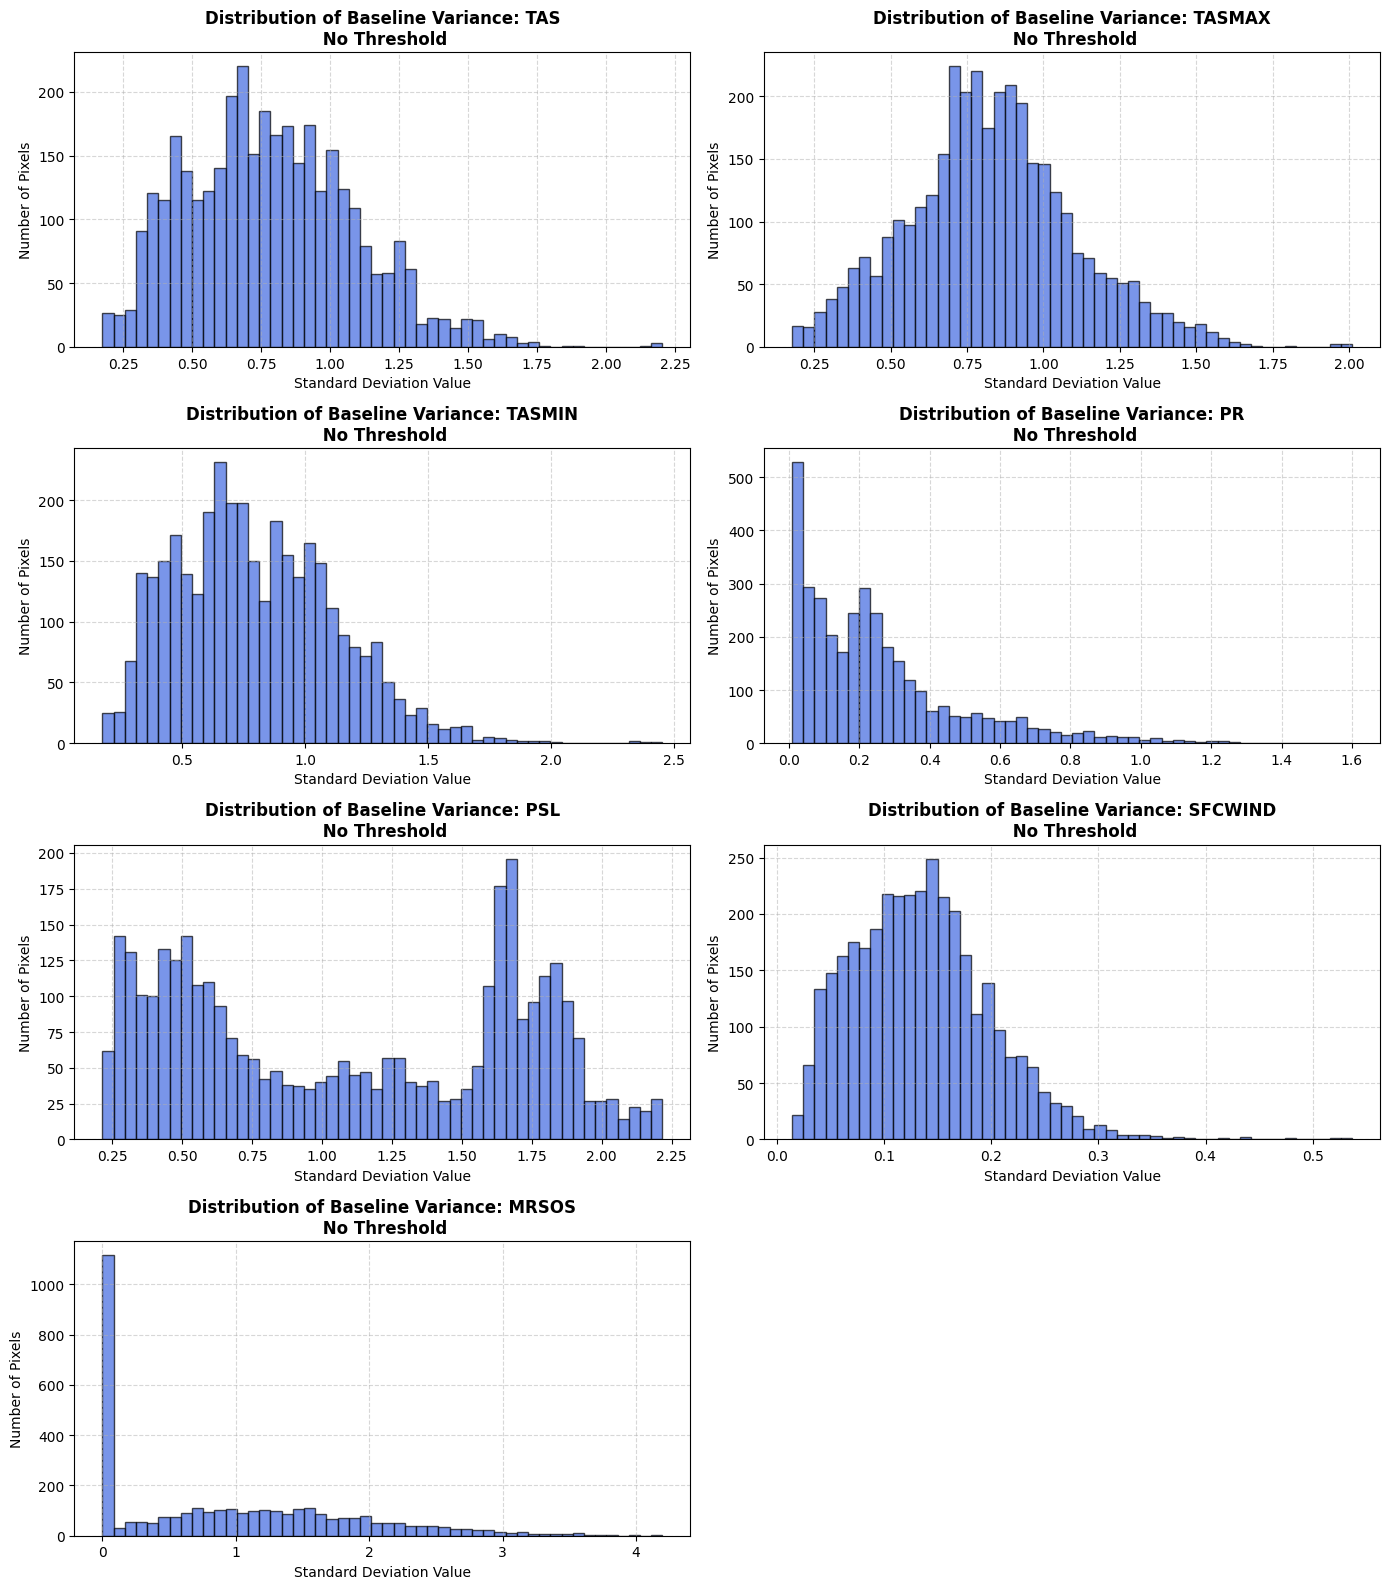

In [20]:
import matplotlib.pyplot as plt
import numpy as np



# Define your variables
var_list = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]

# Create the grid
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.ravel() 

for i, var_name in enumerate(var_list):
    # Flatten the specific variable's map
    var_data = var_std_array[i].ravel()
    
    # Filter out NaNs for clean plotting
    clean_data = var_data[~np.isnan(var_data)]
    
    # Plot histogram
    axes[i].hist(clean_data, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
    
    axes[i].set_title(f"Distribution of Baseline Variance: {var_name.upper()}\n No Threshold", fontsize=12, fontweight='bold')

    axes[i].set_xlabel("Standard Deviation Value")
    axes[i].set_ylabel("Number of Pixels")
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Hide the empty 8th slot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# looking at max mrsos value 
mrsos_max = np.max(X_data[:, 6, :, :])
print(f"MRSOS Max right out of the function: {mrsos_max}")

In [ ]:
import xarray as xr 

# save tensor prep nc file
ds = xr.Dataset(
    data_vars={
        "x_data": (["sample", "variable", "lon", "lat"], X_data),
        "y_label": (["sample", "label_dim"], y_data),
    }
)

# 3. Export straight to NetCDF
ds.to_netcdf("/Users/sophiekim/Desktop/help/cnn_tensors_prep.nc")

### **big function**

early period: 2015-2024

late period: 2055-2064

scenario: ssp119

In [ ]:
# Imports
import os
import sys
import netCDF4 as nc
import pandas as pd
import numpy as np
import xarray as xr
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import datetime

In [ ]:
def get_gradients(inputs, model, top_pred_idx=None):
    """Computes the gradients of outputs w.r.t input image.

    Args:
        inputs: 2D/3D/4D matrix of samples
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.

    Returns:
        Gradients of the predictions w.r.t img_input
    """
    inputs = tf.cast(inputs, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(inputs)
        
        # Run the forward pass of the layer and record operations on GradientTape
        preds = model(inputs, training=False)  
        
        # For classification, grab the top class
        if top_pred_idx is not None:
            preds = preds[:, top_pred_idx]
        
    # Use the gradient tape to automatically retrieve the gradients of the trainable variables with respect to the loss       
    grads = tape.gradient(preds, inputs)

    return grads

In [ ]:
def get_integrated_gradients(inputs, model, baseline=None, num_steps=50, top_pred_idx=None):
    # Ensure inputs and baseline are float32
    inputs = inputs.astype(np.float32)
    
    if baseline is None:
        # Fallback to zeros if no baseline provided
        baseline = np.zeros_like(inputs).astype(np.float32)
    else:
        baseline = baseline.astype(np.float32)
        # Ensure baseline has a leading dimension if it's a single mean map
        if baseline.ndim == inputs.ndim - 1:
            baseline = np.expand_dims(baseline, axis=0)

    # Generate interpolation steps
    # We use np.linspace to create the scaling factors (alphas)
    alphas = np.linspace(0.0, 1.0, num_steps + 1)
    
    # Compute Gradients along the path
    # We iterate through the interpolation path from baseline to input
    all_grads = []
    for alpha in alphas:
        # Interpolate: baseline + alpha * (input - baseline)
        step_input = baseline + alpha * (inputs - baseline)
        
        # Get gradients for this specific step
        grad = get_gradients(step_input, model, top_pred_idx=top_pred_idx)
        all_grads.append(grad)
    
    # Convert to tensor for averaging
    # Shape: (num_steps + 1, batch, vars, lat, lon)
    all_grads = tf.convert_to_tensor(all_grads, dtype=tf.float32)

    # Approximate the integral (Trapezoidal Rule)
    # Average the gradients of adjacent steps
    grads_at_step_ends = (all_grads[:-1] + all_grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads_at_step_ends, axis=0)

    # Final IG calculation: (input - baseline) * average gradient
    integrated_grads = (inputs - baseline) * avg_grads.numpy()
    
    return integrated_grads

In [ ]:
def cnn_training(X_data, y_data, learning_rate=0.0001, epochs=500, batch_size=64):
    # prep indices
    n_samples = X_data.shape[0]
    indices = np.arange(n_samples) # [0, 1, 2, ..., N-1]

    X = np.transpose(X_data, (0, 2, 3, 1))  # (N, lat, lon, 7)
    y = y_data.astype(np.float32)           # (N, 1)

    
    # split test set (50 samples) 
        # passing indices to keep track of the indices that are going in the set 
    X_rem, X_test, y_rem, y_test, idx_rem, test_indices = train_test_split(
        X, y, indices,
        test_size=50,
        stratify=y
    )

    # val split (from remaning 450 samples)
    X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
        X_rem, y_rem, idx_rem,
        test_size=50,
        stratify=y_rem
    )

    
    lat, lon = X_train.shape[1], X_train.shape[2]
    model = models.Sequential([
        layers.Input(shape=(lat, lon, 7)),
        
        #  CNN block (64 filters) with two convs, then pool
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CNN block 32 kernels (conv + pool)
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CNN block 16 kernels (conv only)
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),             
        layers.Dense(50, activation="relu"),
        layers.Dense(10, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True,
        verbose=2
    )

    # train model 
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Return everything needed for the large loop
    return model, X_train, y_train, X_test, y_test, test_indices, history

In [ ]:
def run_climate_experiment(scenario, early_start, late_start, model_list, data_path):

    # initializing list to store results from each early/late period iteration
    all_results = []
    X_data, y_data, std_idk = get_cnn_tensors(model_list, 'ssp119', data_path, use_anomaly=True) 
    # st_early=2015, end_early=2024, st_late=2055, end_late=2064,

    # training data 
    # ADDING HISTORY FOR LOSS CURVE
    model, X_train, y_train, X_test, y_test, test_idx, history = cnn_training(X_data, y_data)

    if history is not None and hasattr(history, 'history'):
        plt.figure(figsize=(8, 4))
        plt.plot(history.history['loss'], label='Training Loss', color='blue')
        if 'val_loss' in history.history:
            plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
        
        plt.title(f"Loss Curve: {scenario} ({early_start} vs {late_start})")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        
        plt.show()      
        plt.close()     
    else:
        print("something went wrong with loss plot")
    
    # predicting
    preds = model.predict(X_test).flatten()

    # --- CALCULATE ACCURACY ---
    # Convert probabilities to binary 0 or 1 using 0.5 as threshold
    binary_preds = (preds >= 0.5).astype(int)
    # Compare to y_test (flattened to match shapes)
    accuracy = np.mean(binary_preds == y_test.flatten())
    
    print(f"--> Iteration Accuracy: {accuracy:.2%}")
    
    # XAI STUFF: 
    # baseline is the mean of early period from training set
    early_idx = np.where(y_train == 0)[0]
    baseline = np.mean(X_train[early_idx], axis=0, keepdims=True)

    # NOTE: need to save baseline prediction values 
    exact_baseline_prediction = model.predict(baseline)
    
    # getting late indices for X_test set 
    late_test_idx = np.where(y_test == 1)[0]
    ig_samples = X_test[late_test_idx]
    
    # integrated gradient calculation based on the early period baseline on the late period stuff 
    ig_output = get_integrated_gradients(ig_samples, model, baseline)
    if hasattr(ig_output, 'numpy'): 
        ig_output = ig_output.numpy()
    
    # getting y test filters 
    y_test_filtered = y_test[late_test_idx].flatten() 
    preds_filtered = preds[late_test_idx]

    # -----UPDATE THE _# TO RUN NUMBER!!--------
    nc_filename = f"/Users/sophiekim/Desktop/help/res_{scenario}_{early_start}_{late_start}.nc"


    
    # Pass the FILTERED data (25 samples) instead of the full test set (50)
    save_iteration_netcdf(ig_output, y_test_filtered, preds_filtered, late_test_idx, test_idx,
                            scenario, early_start, late_start, nc_filename)
    
    final_accuracy = np.mean((preds >= 0.5).astype(int) == y_test.flatten())
    print(f"final accuracy: {final_accuracy: .2%}")

    # making test idx values strings so that can add all the indices for that yr combo iteration as one row in csv file
    test_idx_str = ", ".join(map(str, test_idx))

    all_results.append({
        'early_yr': early_start,
        'late_yr': late_start,
        'scenario': scenario, 
        'mean_pred': np.mean(preds), 
        'accuracy': final_accuracy,
        'test_indices': test_idx_str
    })

    
    del ig_output, X_data, y_data, X_train, y_train, X_test
    if all_results:
        summary_df = pd.DataFrame(all_results)
        
        #timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

        summary_df.to_csv(f"/Users/sophiekim/Desktop/help/experiment_summary_{user}.csv", mode='a', 
                                   header=not os.path.exists("experiment_summary.csv"), 
                                   index=False)
        print("DONE!")
    else:
        print("U MESSED UP!")

In [ ]:
def save_iteration_netcdf(ig_data, y_true, y_pred, late_test_idx, test_idx, scenario, early, late, filename):
    """
    Saves a single iteration's spatial heatmaps to NetCDF.
    Squeezes 4D tensors to 3D to ensure Xarray dimension compatibility.
    """
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    
    test_idx_filtered = test_idx[late_test_idx]

    ds = xr.Dataset(
        data_vars={
            "ig_heatmaps": (("sample", "lat", "lon", "feature"), ig_data),
            "y_true": (("sample",), y_true),
            "y_pred": (("sample",), y_pred), 
            "test_idx_filtered": (("sample",), test_idx_filtered)
        },
        coords={
            "scenario": scenario,
            "early_yr": early,
            "late_yr": late
        }
    )
    
    ds.to_netcdf(filename)

In [ ]:
results = run_climate_experiment('ssp119', 2015, 2055, model_list, data_path)

### **investigation**

In [ ]:
import numpy as np
import netCDF4 as nc

file_path = '/Users/sophiekim/Desktop/help/cnn_tensors_prep.nc'
var_list = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]

with nc.Dataset(file_path, 'r') as cnn_tensors:
    x_data = cnn_tensors['x_data'][:] # btw: shape is sample (500), var (7), lon (144), lat (73)
    
    # going thru each var to find max and min values 
    for i, var_name in enumerate(var_list):
        var_slice = x_data[:, i, :, :]
        print(f"{var_name:<8} | max: {np.max(var_slice):>12.2f} | min: {np.min(var_slice):>12.2f}") 

In [ ]:
import numpy as np
import netCDF4 as nc

file_path = '/Users/sophiekim/Desktop/help/cnn_tensors_prep.nc' 

with nc.Dataset(file_path, 'r') as ds:
    # grabbing mrsos 
    mrsos_data = ds['x_data'][:, 6, :, :] # btw: shape is sample (500), var (7), lon (144), lat (73)
    
    # finding max val of mrsos
    max_val = np.max(mrsos_data)
    # returning where sample, lon, and lat has max mrsos value 
    indices = np.where(mrsos_data == max_val)
    
    print(f"found {len(indices[0])} occurrences of the massive value: {max_val}\n")
    
    # print the first 10 occurences of big value
    for i in range(min(10, len(indices[0]))):
        samp_idx = indices[0][i]
        lon_idx = indices[1][i]
        lat_idx = indices[2][i]
        
        print(f"sample: {samp_idx} | lon index: {lon_idx} | lat index: {lat_idx}")

In [ ]:
import matplotlib.pyplot as plt

file_path = '/Users/sophiekim/Desktop/help/res_ssp119_2015_2055.nc' 

with nc.Dataset(file_path, 'r') as ds:
    # grabbing mrsos from ig data (samples, lat, lon, var)
    ig_data = ds['ig_heatmaps'][:, :, :, 6]

    avg_mrsos = np.mean(np.abs(ig_data), axis=0)
    plt.figure(figsize=(10, 5))
    plt.imshow(avg_mrsos.T, cmap='coolwarm', origin='lower') 
    plt.colorbar(label='IG absolute values')
    plt.title('IG heatmap for mrsos')
    plt.show()

#### **simple bar chart for var importance for the one run**

In [ ]:
import matplotlib.pyplot as plt


file_path = '/Users/sophiekim/Desktop/help/res_ssp119_2015_2055.nc'
var_list = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]

with nc.Dataset(file_path, 'r') as ds:
    # shape is (sample=25, lat=144, lon=73, feature=7)
    ig_data = ds['ig_heatmaps'][:] 

# average across samples and location
global_importance = np.nanmean(np.abs(ig_data), axis=(0, 1, 2))

plt.figure(figsize=(10, 6))
plt.bar(var_list, global_importance)

plt.title('variable importance for one CNN run (early=2015, late=2055)')
plt.ylabel('IG abs value')
plt.xlabel('climate var')
plt.show()
